# Latency-aware open-weight LLM router — data-science MVP

This notebook turns `llm_router_project_scope_2.md` into an executable experiment. It is deliberately split into small, inspectable stages, and **every numbered section ends with a debug/validation cell**.

## What is being learned?

One prompt encoder feeds three heads:

1. predicted quality for every candidate model;
2. predicted output-token count for every candidate model;
3. a soft-oracle policy distribution over candidate models.

At inference time, the policy is not allowed to route freely. The selector:

- keeps models predicted to be within `epsilon` of the best predicted quality;
- estimates warm latency with `latency = intercept + slope × predicted_output_tokens`;
- selects the lowest-latency eligible model;
- falls back to the strongest model when calibrated confidence is low.

## Important experimental boundary

RouterBench is useful for validating preprocessing, oracle construction, and representation learning on existing outcomes. It does **not** contain representative local Colab latency for this final candidate pool. Final heads and held-out metrics therefore require rows generated by the exact local models on the exact GPU.

## Candidate pool

- `qwen3.5-9b-4bit` — strongest conservative fallback;
- `qwen3.5-2b-4bit` — fast autoregressive option;
- `fast-dllm-v2-1.5b` — diffusion option; replace with 7B only if its smoke test fits.

Primary references:

- [Project scope v2](../llm_router_project_scope_2.md)
- [RouterBench repository](https://github.com/withmartian/routerbench)
- [RouterBench dataset](https://huggingface.co/datasets/withmartian/routerbench)
- [ModernBERT base](https://huggingface.co/answerdotai/ModernBERT-base)
- [Fast-dLLM v2 official code](https://github.com/NVlabs/Fast-dLLM/tree/main/v2)

> Start with `DEMO_MODE=True`. This runs the complete statistical pipeline on synthetic-but-structured measurements without downloading an LLM. Once all checks pass, provide a normalized local measurement file and switch it off.

## 1. Environment, configuration, and reproducibility

The first install line is intended for a fresh Colab runtime. It is disabled by default so rerunning the notebook does not mutate an existing environment unexpectedly.

In [1]:
# Colab only: flip this once in a fresh runtime, execute, then set it back to False.
INSTALL_OPTIONAL_DEPENDENCIES = False

if INSTALL_OPTIONAL_DEPENDENCIES:
    %pip install -q "transformers>=4.48" datasets accelerate evaluate             scikit-learn seaborn pyarrow huggingface_hub

# Install Unsloth separately only in the Qwen benchmarking runtime because its
# CUDA/PyTorch pins may differ from the router-training runtime:
# %pip install -q unsloth

In [2]:
from __future__ import annotations

import gc
import importlib.util
import json
import math
import os
import platform
import random
import re
import tempfile
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

@dataclass(frozen=True)
class Config:
    seed: int = 42
    demo_mode: bool = True
    demo_prompts: int = 450
    measurements_path: str = "data/measurements.parquet"
    candidate_models: tuple[str, ...] = (
        "qwen3.5-9b-4bit",
        "qwen3.5-2b-4bit",
        "fast-dllm-v2-1.5b",
    )
    strongest_model: str = "qwen3.5-9b-4bit"
    test_fraction: float = 0.15
    validation_fraction: float = 0.15
    oracle_epsilon: float = 0.05
    oracle_latency_weight: float = 0.06
    oracle_temperature: float = 0.08
    minimum_quality_retention: float = 0.98
    max_router_length: int = 512
    modernbert_checkpoint: str = "answerdotai/ModernBERT-base"
    modernbert_epochs: int = 3
    modernbert_batch_size: int = 16
    modernbert_learning_rate: float = 2e-5

CFG = Config()
MODELS = list(CFG.candidate_models)
MODEL_TO_INDEX = {name: i for i, name in enumerate(MODELS)}

def seed_everything(seed: int = CFG.seed) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if importlib.util.find_spec("torch") is not None:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

seed_everything()
print(asdict(CFG))

{'seed': 42, 'demo_mode': True, 'demo_prompts': 450, 'measurements_path': 'data/measurements.parquet', 'candidate_models': ('qwen3.5-9b-4bit', 'qwen3.5-2b-4bit', 'fast-dllm-v2-1.5b'), 'strongest_model': 'qwen3.5-9b-4bit', 'test_fraction': 0.15, 'validation_fraction': 0.15, 'oracle_epsilon': 0.05, 'oracle_latency_weight': 0.06, 'oracle_temperature': 0.08, 'minimum_quality_retention': 0.98, 'max_router_length': 512, 'modernbert_checkpoint': 'answerdotai/ModernBERT-base', 'modernbert_epochs': 3, 'modernbert_batch_size': 16, 'modernbert_learning_rate': 2e-05}


In [3]:
# DEBUG 1 — fail early when the runtime or configuration is inconsistent.
print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("Working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Optional packages:", {
    name: importlib.util.find_spec(name) is not None
    for name in ["torch", "transformers", "datasets", "unsloth"]
})

assert len(MODELS) == len(set(MODELS)), "Candidate names must be unique."
assert CFG.strongest_model in MODELS
assert 0 < CFG.oracle_temperature
assert 0 <= CFG.validation_fraction < 1
assert 0 <= CFG.test_fraction < 1
assert CFG.validation_fraction + CFG.test_fraction < 1
print("DEBUG 1 passed.")

Python: 3.14.3
Platform: Windows-11-10.0.26200-SP0
Working directory: C:\Users\bruno\Documents\LLM_Router\notebooks
Project root: C:\Users\bruno\Documents\LLM_Router
Optional packages: {'torch': False, 'transformers': False, 'datasets': False, 'unsloth': False}
DEBUG 1 passed.


## 2. Data contract and a structured dry-run dataset

The canonical table is long-form: one row per `(prompt_id, model)`. Keep `load_time_s` separate from warm generation latency. `ttft_s` may be missing when a non-streaming generation API cannot expose the first token reliably.

Required columns:

`prompt_id, prompt, task, model, response, quality, ttft_s, total_latency_s, output_tokens, tokens_per_second`

Operational columns such as `load_time_s`, `peak_vram_gb`, decoding configuration, GPU name, and run ID should also be retained when available.

The synthetic generator below is not evidence about real model performance. Its only job is to expose leakage, shape, calibration, and routing bugs cheaply.

In [4]:
REQUIRED_COLUMNS = {
    "prompt_id", "prompt", "task", "model", "response", "quality",
    "ttft_s", "total_latency_s", "output_tokens", "tokens_per_second",
}

TASKS = ["gsm8k", "mmlu", "mbpp", "commonsenseqa", "instruction"]

def make_demo_measurements(n_prompts: int, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    model_specs = {
        "qwen3.5-9b-4bit": dict(q=0.88, q_decay=0.25, intercept=0.16, slope=0.018, tok_mult=1.10),
        "qwen3.5-2b-4bit": dict(q=0.73, q_decay=0.34, intercept=0.08, slope=0.008, tok_mult=0.90),
        "fast-dllm-v2-1.5b": dict(q=0.76, q_decay=0.29, intercept=0.11, slope=0.006, tok_mult=1.00),
    }
    task_bonus = {
        "qwen3.5-9b-4bit": {"gsm8k": 0.04, "mmlu": 0.03, "mbpp": 0.02},
        "qwen3.5-2b-4bit": {"commonsenseqa": 0.05, "instruction": 0.03},
        "fast-dllm-v2-1.5b": {"mbpp": 0.08, "instruction": 0.04},
    }
    templates = {
        "gsm8k": "Solve this grade-school word problem and show the final number: case {i}, difficulty {d:.2f}.",
        "mmlu": "Choose the best answer for multiple-choice concept {i}; estimated difficulty {d:.2f}.",
        "mbpp": "Write a Python function for programming task {i}; estimated difficulty {d:.2f}.",
        "commonsenseqa": "Answer commonsense scenario {i} with one choice; ambiguity {d:.2f}.",
        "instruction": "Follow all constraints in instruction {i}; complexity {d:.2f}.",
    }
    rows = []
    for i in range(n_prompts):
        task = TASKS[i % len(TASKS)]
        difficulty = float(np.clip(rng.beta(2.2, 2.0), 0.02, 0.98))
        prompt = templates[task].format(i=i, d=difficulty)
        base_tokens = 28 + 150 * difficulty + (35 if task in {"mbpp", "instruction"} else 0)
        for model_name in MODELS:
            spec = model_specs[model_name]
            complementarity = 0.07 * math.sin(i * (MODEL_TO_INDEX[model_name] + 1) / 9)
            quality = (
                spec["q"] - spec["q_decay"] * difficulty
                + task_bonus.get(model_name, {}).get(task, 0.0)
                + complementarity + rng.normal(0, 0.045)
            )
            quality = float(np.clip(quality, 0.0, 1.0))
            output_tokens = int(max(4, round(base_tokens * spec["tok_mult"] + rng.normal(0, 12))))
            total_latency = max(
                0.01,
                spec["intercept"] + spec["slope"] * output_tokens
                + rng.normal(0, 0.06 + 0.0008 * output_tokens),
            )
            ttft = max(0.005, spec["intercept"] * 0.65 + rng.normal(0, 0.01))
            rows.append({
                "prompt_id": f"demo-{i:05d}",
                "prompt": prompt,
                "task": task,
                "model": model_name,
                "response": f"[synthetic response from {model_name}]",
                "quality": quality,
                "ttft_s": ttft,
                "total_latency_s": total_latency,
                "output_tokens": output_tokens,
                "tokens_per_second": output_tokens / total_latency,
                "load_time_s": np.nan,
                "is_warm": True,
            })
    return pd.DataFrame(rows)

def load_measurements(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    if not path.exists():
        raise FileNotFoundError(
            f"{path} does not exist. Keep demo_mode=True or create the normalized measurement file."
        )
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError("Use .parquet or .csv for normalized measurements.")

measurements = (
    make_demo_measurements(CFG.demo_prompts, CFG.seed)
    if CFG.demo_mode
    else load_measurements(CFG.measurements_path)
)
measurements.head()

,prompt_id,prompt,task,model,response,quality,ttft_s,total_latency_s,output_tokens,tokens_per_second,load_time_s,is_warm
0,demo-00000,"Solve this grade-school word problem and show the final number: case 0, difficulty 0.45.",gsm8k,qwen3.5-9b-4bit,[synthetic response from qwen3.5-9b-4bit],0.719840,0.100838,1.778773,89,50.034500,NaN,True
1,demo-00000,"Solve this grade-school word problem and show the final number: case 0, difficulty 0.45.",gsm8k,qwen3.5-2b-4bit,[synthetic response from qwen3.5-2b-4bit],0.576430,0.059778,0.794231,76,95.690012,NaN,True
2,demo-00000,"Solve this grade-school word problem and show the final number: case 0, difficulty 0.45.",gsm8k,fast-dllm-v2-1.5b,[synthetic response from fast-dllm-v2-1.5b],0.632630,0.062907,0.832817,109,130.881035,NaN,True
3,demo-00001,Choose the best answer for multiple-choice concept 1; estimated difficulty 0.44.,mmlu,qwen3.5-9b-4bit,[synthetic response from qwen3.5-9b-4bit],0.799464,0.102455,2.036266,95,46.654031,NaN,True
4,demo-00001,Choose the best answer for multiple-choice concept 1; estimated difficulty 0.44.,mmlu,qwen3.5-2b-4bit,[synthetic response from qwen3.5-2b-4bit],0.576581,0.055654,0.786006,80,101.780350,NaN,True


In [5]:
# Optional Stage-A loader: RouterBench is a wide pickle with existing-model
# responses/scores. Use it to validate ideas or pretrain an encoder, not as a
# source of latency labels for this notebook's final local candidates.
LOAD_ROUTERBENCH = False

def load_routerbench_zero_shot() -> tuple[pd.DataFrame, list[str]]:
    from huggingface_hub import hf_hub_download

    warnings.warn(
        "Pickle files can execute code while loading. This downloads from the "
        "official withmartian/routerbench repository; verify provenance before use."
    )
    pickle_path = hf_hub_download(
        repo_id="withmartian/routerbench",
        filename="routerbench_0shot.pkl",
        repo_type="dataset",
    )
    frame = pd.read_pickle(pickle_path)
    existing_models = sorted(
        column.removesuffix("|model_response")
        for column in frame.columns
        if column.endswith("|model_response")
    )
    return frame, existing_models

if LOAD_ROUTERBENCH:
    routerbench_wide, routerbench_models = load_routerbench_zero_shot()
    print("RouterBench shape:", routerbench_wide.shape)
    print("Existing outcome models:", routerbench_models)
    display(routerbench_wide.head())
    display(pd.Series(routerbench_wide.columns, name="column").to_frame())

In [6]:
# DEBUG 2 — schema, ranges, duplicates, and complete prompt/model panels.
missing = REQUIRED_COLUMNS - set(measurements.columns)
assert not missing, f"Missing columns: {sorted(missing)}"
assert not measurements.duplicated(["prompt_id", "model"]).any(), "Duplicate prompt/model rows."
assert measurements["prompt_id"].nunique() * len(MODELS) == len(measurements)
assert set(measurements["model"].unique()) == set(MODELS)
assert measurements["quality"].between(0, 1).all()
assert (measurements["output_tokens"] > 0).all()
assert (measurements["total_latency_s"] > 0).all()
assert measurements[["prompt_id", "prompt", "task", "model"]].notna().all().all()

coverage = pd.crosstab(measurements["task"], measurements["model"])
display(coverage)
display(
    measurements.groupby("model")[["quality", "total_latency_s", "output_tokens"]]
    .agg(["mean", "std", "min", "max"]).round(3)
)
print("DEBUG 2 passed.")

model,fast-dllm-v2-1.5b,qwen3.5-2b-4bit,qwen3.5-9b-4bit
task,,,
commonsenseqa,90,90,90
gsm8k,90,90,90
instruction,90,90,90
mbpp,90,90,90
mmlu,90,90,90


quality                      total_latency_s                \
                     mean    std    min    max            mean    std    min   
model                                                                          
fast-dllm-v2-1.5b   0.635  0.095  0.339  0.939           0.830  0.287  0.165   
qwen3.5-2b-4bit     0.574  0.100  0.328  0.835           0.937  0.335  0.224   
qwen3.5-9b-4bit     0.769  0.086  0.526  1.000           2.502  0.775  0.415   

                         output_tokens                   
                     max          mean     std min  max  
model                                                    
fast-dllm-v2-1.5b  1.752       118.962  39.008  29  203  
qwen3.5-2b-4bit    1.739       107.380  37.235  23  198  
qwen3.5-9b-4bit    4.406       130.918  42.451  23  236

DEBUG 2 passed.


## 3. Resumable warm-inference collection

Run one candidate at a time:

1. load once and record load time;
2. smoke-test a few prompts;
3. warm up;
4. benchmark all assigned prompts with identical decoding settings;
5. append each completed row to a per-model cache;
6. unload, collect garbage, and clear the CUDA cache.

The generic harness below is executable. The model adapters return `(response_text, output_token_count)`. Non-streaming `.generate()` cannot measure TTFT honestly, so it stores `NaN` instead of inventing a value.

In [7]:
def cuda_synchronize() -> None:
    if importlib.util.find_spec("torch") is not None:
        import torch
        if torch.cuda.is_available():
            torch.cuda.synchronize()

def reset_peak_vram() -> None:
    if importlib.util.find_spec("torch") is not None:
        import torch
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

def peak_vram_gb() -> float:
    if importlib.util.find_spec("torch") is not None:
        import torch
        if torch.cuda.is_available():
            return float(torch.cuda.max_memory_allocated() / 1024**3)
    return math.nan

def unload_model(*objects) -> None:
    for obj in objects:
        del obj
    gc.collect()
    if importlib.util.find_spec("torch") is not None:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

def benchmark_candidate(
    prompt_frame: pd.DataFrame,
    model_name: str,
    generate_one: Callable[[str], tuple[str, int]],
    cache_path: str | Path,
    warmup_prompts: int = 2,
    load_time_s: float = math.nan,
) -> pd.DataFrame:
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
    else:
        cached = pd.DataFrame()
    completed = set(cached["prompt_id"].astype(str)) if len(cached) else set()

    for prompt in prompt_frame["prompt"].head(warmup_prompts):
        _ = generate_one(prompt)
    cuda_synchronize()

    new_rows = []
    for row in prompt_frame.itertuples(index=False):
        if str(row.prompt_id) in completed:
            continue
        reset_peak_vram()
        cuda_synchronize()
        started = time.perf_counter()
        response, output_tokens = generate_one(row.prompt)
        cuda_synchronize()
        latency = time.perf_counter() - started
        result = {
            "prompt_id": str(row.prompt_id),
            "prompt": row.prompt,
            "task": row.task,
            "model": model_name,
            "response": response,
            "quality": np.nan,  # filled by the evaluation stage
            "ttft_s": np.nan,  # requires a streaming/callback adapter
            "total_latency_s": latency,
            "output_tokens": int(output_tokens),
            "tokens_per_second": output_tokens / latency,
            "load_time_s": load_time_s,
            "peak_vram_gb": peak_vram_gb(),
            "is_warm": True,
        }
        new_rows.append(result)
        # Checkpoint every completed response. Parquet can replace CSV at scale.
        pd.concat([cached, pd.DataFrame(new_rows)], ignore_index=True).to_csv(cache_path, index=False)
    return pd.concat([cached, pd.DataFrame(new_rows)], ignore_index=True)

def build_unsloth_qwen_generator(
    checkpoint: str,
    max_seq_length: int = 2048,
    max_new_tokens: int = 512,
):
    from unsloth import FastLanguageModel
    import torch

    loaded_at = time.perf_counter()
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=checkpoint,
        max_seq_length=max_seq_length,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)
    load_time_s = time.perf_counter() - loaded_at

    def generate_one(prompt: str) -> tuple[str, int]:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        input_length = inputs["input_ids"].shape[1]
        with torch.inference_mode():
            generated = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
            )
        new_ids = generated[0, input_length:]
        return tokenizer.decode(new_ids, skip_special_tokens=True), int(new_ids.numel())

    return model, tokenizer, generate_one, load_time_s

def build_fast_dllm_generator(
    checkpoint: str = "Efficient-Large-Model/Fast_dLLM_v2_1.5B",
    max_new_tokens: int = 512,
    block_size: int = 32,
    small_block_size: int = 8,
    threshold: float = 0.9,
):
    from transformers import AutoModelForCausalLM, AutoTokenizer
    import torch

    loaded_at = time.perf_counter()
    model = AutoModelForCausalLM.from_pretrained(
        checkpoint,
        torch_dtype="auto",
        device_map="cuda:0",
        trust_remote_code=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)
    load_time_s = time.perf_counter() - loaded_at

    def generate_one(prompt: str) -> tuple[str, int]:
        text = tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt}],
            tokenize=False,
            add_generation_prompt=True,
        )
        inputs = tokenizer([text], return_tensors="pt").to(model.device)
        input_length = inputs["input_ids"].shape[1]
        with torch.inference_mode():
            generated = model.generate(
                inputs["input_ids"],
                tokenizer=tokenizer,
                block_size=block_size,
                small_block_size=small_block_size,
                threshold=threshold,
                max_new_tokens=max_new_tokens,
            )
        new_ids = generated[0, input_length:]
        return tokenizer.decode(new_ids, skip_special_tokens=True), int(new_ids.numel())

    return model, tokenizer, generate_one, load_time_s

RUN_REAL_BENCHMARKS = False
if RUN_REAL_BENCHMARKS:
    raise RuntimeError(
        "Set your exact checkpoints and prompt subset first; benchmark one loaded model per runtime."
    )

In [8]:
# DEBUG 3 — exercise timing + resumability with a fake generator.
smoke_prompts = measurements[["prompt_id", "prompt", "task"]].drop_duplicates().head(3)

def fake_generate(prompt: str) -> tuple[str, int]:
    token_count = max(1, len(prompt.split()) // 2)
    return "fake response", token_count

smoke_cache = Path(tempfile.gettempdir()) / f"router_harness_smoke_{os.getpid()}.csv"
if smoke_cache.exists():
    smoke_cache.unlink()
first_pass = benchmark_candidate(smoke_prompts, "debug-model", fake_generate, smoke_cache, warmup_prompts=1)
second_pass = benchmark_candidate(smoke_prompts, "debug-model", fake_generate, smoke_cache, warmup_prompts=1)
assert len(first_pass) == len(smoke_prompts)
assert len(second_pass) == len(smoke_prompts), "Resume should not duplicate completed prompts."
assert (first_pass["total_latency_s"] > 0).all()
assert (first_pass["output_tokens"] > 0).all()
smoke_cache.unlink(missing_ok=True)
print("DEBUG 3 passed.")

DEBUG 3 passed.


## 4. Quality labels

Prefer deterministic task metrics whenever a reference answer exists. Use an open-weight judge only for genuinely open-ended tasks, version the judge prompt, and audit a sample manually.

MBPP deserves a sandboxed unit-test runner rather than string matching; this starter deliberately does not execute untrusted generated code inside the notebook.

In [9]:
def normalize_answer(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return re.sub(r"[^a-z0-9.\- ]", "", text)

def last_number(text: str) -> str | None:
    matches = re.findall(r"-?\d+(?:,\d{3})*(?:\.\d+)?", str(text))
    return matches[-1].replace(",", "") if matches else None

def final_choice(text: str) -> str | None:
    # Use the last isolated A-E choice, which is usually the final answer.
    matches = re.findall(r"(?i)(?:^|\W)([A-E])(?:\W|$)", str(text))
    return matches[-1].upper() if matches else None

def deterministic_quality(response: str, reference: str, task: str) -> float:
    if task == "gsm8k":
        prediction = last_number(response)
        target = last_number(reference)
        return float(prediction is not None and prediction == target)
    if task in {"mmlu", "commonsenseqa"}:
        prediction = final_choice(response)
        target = final_choice(reference)
        return float(prediction is not None and prediction == target)
    if task == "mbpp":
        raise NotImplementedError("Run official/sandboxed MBPP tests; do not use text equality.")
    return float(normalize_answer(response) == normalize_answer(reference))

# Example once references are joined:
# mask = scored_rows["task"].isin(["gsm8k", "mmlu", "commonsenseqa"])
# scored_rows.loc[mask, "quality"] = scored_rows.loc[mask].apply(
#     lambda r: deterministic_quality(r.response, r.reference_answer, r.task), axis=1
# )

In [10]:
# DEBUG 4 — metric unit tests catch common answer-extraction regressions.
assert deterministic_quality("Reasoning... final answer is 1,234.", "#### 1234", "gsm8k") == 1.0
assert deterministic_quality("I first considered B, but the answer is (D).", "D", "mmlu") == 1.0
assert deterministic_quality("  Hello, WORLD! ", "hello world", "instruction") == 1.0
try:
    deterministic_quality("def f(): pass", "tests", "mbpp")
except NotImplementedError:
    pass
else:
    raise AssertionError("MBPP must not silently use an invalid text metric.")
print("DEBUG 4 passed.")

DEBUG 4 passed.


## 5. Prompt-level split and wide modeling table

Split by `prompt_id` before fitting anything. All rows for a prompt must stay in the same partition. Latency coefficients, normalization statistics, the tokenizer/vectorizer, and learned models are fitted on train only.

In [11]:
def make_prompt_table(rows: pd.DataFrame, models: list[str]) -> pd.DataFrame:
    metadata = (
        rows[["prompt_id", "prompt", "task"]]
        .drop_duplicates("prompt_id")
        .set_index("prompt_id")
    )
    table = metadata.copy()
    for value in ["quality", "output_tokens", "total_latency_s", "ttft_s"]:
        pivot = rows.pivot(index="prompt_id", columns="model", values=value).reindex(columns=models)
        pivot.columns = [f"{value}__{model}" for model in models]
        table = table.join(pivot)
    return table.reset_index()

prompt_table = make_prompt_table(measurements, MODELS)
prompt_ids = prompt_table["prompt_id"].to_numpy()
prompt_tasks = prompt_table["task"].to_numpy()

train_val_ids, test_ids = train_test_split(
    prompt_ids,
    test_size=CFG.test_fraction,
    random_state=CFG.seed,
    stratify=prompt_tasks,
)
train_val_tasks = prompt_table.set_index("prompt_id").loc[train_val_ids, "task"].to_numpy()
relative_validation_size = CFG.validation_fraction / (1.0 - CFG.test_fraction)
train_ids, validation_ids = train_test_split(
    train_val_ids,
    test_size=relative_validation_size,
    random_state=CFG.seed + 1,
    stratify=train_val_tasks,
)

split_by_id = {
    **{x: "train" for x in train_ids},
    **{x: "validation" for x in validation_ids},
    **{x: "test" for x in test_ids},
}
prompt_table["split"] = prompt_table["prompt_id"].map(split_by_id)
measurements["split"] = measurements["prompt_id"].map(split_by_id)

def columns_for(prefix: str) -> list[str]:
    return [f"{prefix}__{model}" for model in MODELS]

def matrix(table: pd.DataFrame, prefix: str) -> np.ndarray:
    return table[columns_for(prefix)].to_numpy(dtype=float)

display(prompt_table.groupby(["split", "task"]).size().unstack(fill_value=0))

task,commonsenseqa,gsm8k,instruction,mbpp,mmlu
split,,,,,
test,14,13,14,14,13
train,62,63,63,63,63
validation,14,14,13,13,14


In [12]:
# DEBUG 5 — verify group isolation and stratification.
split_sets = {
    name: set(prompt_table.loc[prompt_table["split"] == name, "prompt_id"])
    for name in ["train", "validation", "test"]
}
assert split_sets["train"].isdisjoint(split_sets["validation"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["validation"].isdisjoint(split_sets["test"])
assert set.union(*split_sets.values()) == set(prompt_table["prompt_id"])
assert prompt_table["split"].notna().all()
assert matrix(prompt_table, "quality").shape == (len(prompt_table), len(MODELS))

global_task_share = prompt_table["task"].value_counts(normalize=True)
for split_name in split_sets:
    share = prompt_table.loc[prompt_table["split"] == split_name, "task"].value_counts(normalize=True)
    assert (share.reindex(global_task_share.index, fill_value=0) - global_task_share).abs().max() < 0.08
print("DEBUG 5 passed.")

DEBUG 5 passed.


## 6. Fit the warm-latency model

For each candidate:

\[
\widehat{L}_m = a_m + b_m\widehat{T}_m
\]

Fit coefficients only from measured training rows. Inspect residuals: a linear token model is a baseline, not a law. If residuals vary systematically with prompt length, task, or diffusion block count, add those features or fit a monotonic nonlinear model.

In [13]:
train_measurements = measurements.loc[measurements["split"] == "train"].copy()
latency_models: dict[str, LinearRegression] = {}
latency_records = []

for model_name in MODELS:
    part = train_measurements.loc[train_measurements["model"] == model_name]
    x = part[["output_tokens"]].to_numpy()
    y = part["total_latency_s"].to_numpy()
    reg = LinearRegression().fit(x, y)
    prediction = np.maximum(1e-6, reg.predict(x))
    latency_models[model_name] = reg
    latency_records.append({
        "model": model_name,
        "intercept_s": float(reg.intercept_),
        "seconds_per_output_token": float(reg.coef_[0]),
        "train_mae_s": mean_absolute_error(y, prediction),
        "train_r2": r2_score(y, prediction),
    })

latency_coefficients = pd.DataFrame(latency_records).set_index("model").loc[MODELS]
display(latency_coefficients.round(4))

# Training-only latency normalization for the soft oracle.
latency_norm_stats = (
    train_measurements.groupby(["task", "model"])["total_latency_s"]
    .agg(["mean", "std"])
    .reset_index()
)
latency_norm_stats["std"] = latency_norm_stats["std"].fillna(0).clip(lower=1e-6)

def normalized_latency_matrix(table: pd.DataFrame) -> np.ndarray:
    stats = latency_norm_stats.set_index(["task", "model"])
    result = np.zeros((len(table), len(MODELS)), dtype=float)
    raw = matrix(table, "total_latency_s")
    for row_idx, task in enumerate(table["task"]):
        for model_idx, model_name in enumerate(MODELS):
            mu = stats.loc[(task, model_name), "mean"]
            sigma = stats.loc[(task, model_name), "std"]
            result[row_idx, model_idx] = (raw[row_idx, model_idx] - mu) / sigma
    return result

latency_z = normalized_latency_matrix(prompt_table)

,intercept_s,seconds_per_output_token,train_mae_s,train_r2
model,,,,
qwen3.5-9b-4bit,0.1492,0.0180,0.1284,0.9558
qwen3.5-2b-4bit,0.0667,0.0081,0.1169,0.8046
fast-dllm-v2-1.5b,0.1224,0.0060,0.1239,0.6764


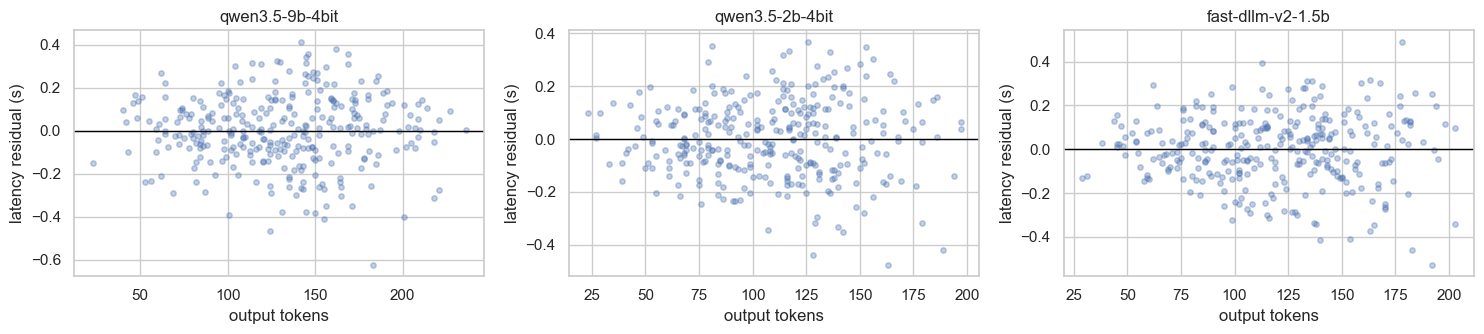

DEBUG 6 passed.


In [14]:
# DEBUG 6 — coefficients and residual diagnostics.
assert np.isfinite(latency_coefficients.to_numpy()).all()
assert (latency_coefficients["seconds_per_output_token"] > 0).all(), (
    "A non-positive slope usually signals noisy measurements or an invalid timing policy."
)
assert np.isfinite(latency_z).all()

fig, axes = plt.subplots(1, len(MODELS), figsize=(15, 3.5), sharey=False)
for ax, model_name in zip(axes, MODELS):
    part = train_measurements.loc[train_measurements["model"] == model_name]
    predicted = latency_models[model_name].predict(part[["output_tokens"]].to_numpy())
    residual = part["total_latency_s"].to_numpy() - predicted
    ax.scatter(part["output_tokens"], residual, alpha=0.35, s=15)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("output tokens")
    ax.set_ylabel("latency residual (s)")
plt.tight_layout()
plt.show()
print("DEBUG 6 passed.")

## 7. Construct quality-gated soft-oracle targets

The oracle is a label generator and an upper bound—not the deployed router.

\[
\mathcal{E}(x)=\{m:Q_m(x)\ge \max_j Q_j(x)-\epsilon\}
\]

\[
S_m=Q_m-\lambda_l\widehat{L}^{\,norm}_m,\qquad
y_m=\operatorname{softmax}(S_m/\tau)\ \text{over eligible models only}
\]

`epsilon`, `lambda_l`, and `tau` are experiment hyperparameters. Compare a small predeclared grid and choose with validation data only; never choose them from test metrics.

In [15]:
def soft_oracle_targets(
    quality: np.ndarray,
    normalized_latency: np.ndarray,
    epsilon: float,
    latency_weight: float,
    temperature: float,
) -> tuple[np.ndarray, np.ndarray]:
    best_quality = quality.max(axis=1, keepdims=True)
    eligible = quality >= (best_quality - epsilon)
    score = quality - latency_weight * normalized_latency
    masked_logits = np.where(eligible, score / temperature, -np.inf)
    row_max = np.max(masked_logits, axis=1, keepdims=True)
    exp_score = np.where(eligible, np.exp(masked_logits - row_max), 0.0)
    targets = exp_score / exp_score.sum(axis=1, keepdims=True)
    return targets, eligible

quality_matrix = matrix(prompt_table, "quality")
oracle_targets, oracle_eligible = soft_oracle_targets(
    quality_matrix,
    latency_z,
    epsilon=CFG.oracle_epsilon,
    latency_weight=CFG.oracle_latency_weight,
    temperature=CFG.oracle_temperature,
)
oracle_winner_idx = oracle_targets.argmax(axis=1)
prompt_table["oracle_winner"] = [MODELS[i] for i in oracle_winner_idx]
display(prompt_table.groupby(["task", "oracle_winner"]).size().unstack(fill_value=0))

oracle_winner,fast-dllm-v2-1.5b,qwen3.5-2b-4bit,qwen3.5-9b-4bit
task,,,
commonsenseqa,7,5,78
gsm8k,5,0,85
instruction,10,3,77
mbpp,17,1,72
mmlu,7,0,83


In [16]:
# DEBUG 7 — probability simplex and strict quality gate.
assert oracle_targets.shape == quality_matrix.shape
assert np.allclose(oracle_targets.sum(axis=1), 1.0, atol=1e-7)
assert (oracle_targets >= 0).all()
assert np.all(oracle_targets[~oracle_eligible] == 0)
assert oracle_eligible.any(axis=1).all()
assert np.isfinite(oracle_targets).all()

eligible_counts = pd.Series(oracle_eligible.sum(axis=1)).value_counts().sort_index()
display(eligible_counts.rename("prompt_count").to_frame())
print("DEBUG 7 passed.")

,prompt_count
1,366
2,78
3,6


DEBUG 7 passed.


## 8. CPU baseline: prove the target and selector before fine-tuning ModernBERT

This baseline uses one TF-IDF representation with three ridge heads. It mirrors the ModernBERT output contract and makes the entire pipeline debuggable on a laptop. It is a sanity baseline, not the final architecture.

In [17]:
prompt_text = (
    "[TASK=" + prompt_table["task"].astype(str) + "] " + prompt_table["prompt"].astype(str)
).to_numpy()
split_masks = {
    split_name: (prompt_table["split"].to_numpy() == split_name)
    for split_name in ["train", "validation", "test"]
}

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
    sublinear_tf=True,
)
x_train = vectorizer.fit_transform(prompt_text[split_masks["train"]])
x_all = vectorizer.transform(prompt_text)

quality_head = Ridge(alpha=2.0).fit(x_train, quality_matrix[split_masks["train"]])
token_log_target = np.log1p(matrix(prompt_table, "output_tokens"))
token_head = Ridge(alpha=2.0).fit(x_train, token_log_target[split_masks["train"]])
policy_log_target = np.log(np.clip(oracle_targets, 1e-6, 1.0))
policy_head = Ridge(alpha=3.0).fit(x_train, policy_log_target[split_masks["train"]])

def stable_softmax(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

baseline_quality_pred = np.clip(quality_head.predict(x_all), 0.0, 1.0)
baseline_token_log_pred = np.maximum(0.0, token_head.predict(x_all))
baseline_policy_prob = stable_softmax(policy_head.predict(x_all))

active_quality_pred = baseline_quality_pred
active_token_log_pred = baseline_token_log_pred
active_policy_prob = baseline_policy_prob
ACTIVE_ROUTER = "tfidf-ridge-debug-baseline"

In [18]:
# DEBUG 8 — output contract and validation prediction error.
n_prompts, n_models = quality_matrix.shape
assert active_quality_pred.shape == (n_prompts, n_models)
assert active_token_log_pred.shape == (n_prompts, n_models)
assert active_policy_prob.shape == (n_prompts, n_models)
assert np.allclose(active_policy_prob.sum(axis=1), 1.0)
assert np.isfinite(active_quality_pred).all()
assert np.isfinite(active_token_log_pred).all()

val = split_masks["validation"]
debug_errors = pd.DataFrame({
    "model": MODELS,
    "quality_rmse": np.sqrt(np.mean((active_quality_pred[val] - quality_matrix[val]) ** 2, axis=0)),
    "token_mae": np.mean(
        np.abs(np.expm1(active_token_log_pred[val]) - matrix(prompt_table, "output_tokens")[val]),
        axis=0,
    ),
}).set_index("model")
display(debug_errors.round(3))
print("DEBUG 8 passed.")

,quality_rmse,token_mae
model,,
qwen3.5-9b-4bit,0.088,24.327
qwen3.5-2b-4bit,0.093,28.317
fast-dllm-v2-1.5b,0.088,27.621


DEBUG 8 passed.


## 9. Final model: ModernBERT with three heads

Flip `RUN_MODERNBERT=True` in a GPU runtime after the dry run passes. The model jointly minimizes:

- quality MSE;
- Smooth-L1 loss on `log(1 + output_tokens)`;
- soft cross-entropy against the oracle distribution.

The quality and token heads provide the constrained selector's inputs. The policy head supplies an auxiliary routing signal and the confidence used by conservative fallback.

In [19]:
RUN_MODERNBERT = False

if RUN_MODERNBERT:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset
    from transformers import AutoModel, AutoTokenizer

    class RouterDataset(Dataset):
        def __init__(self, indices: np.ndarray):
            self.indices = np.asarray(indices)

        def __len__(self):
            return len(self.indices)

        def __getitem__(self, item):
            i = int(self.indices[item])
            return {
                "text": prompt_text[i],
                "quality": torch.tensor(quality_matrix[i], dtype=torch.float32),
                "token_log": torch.tensor(token_log_target[i], dtype=torch.float32),
                "oracle": torch.tensor(oracle_targets[i], dtype=torch.float32),
                "row_index": i,
            }

    tokenizer = AutoTokenizer.from_pretrained(CFG.modernbert_checkpoint)

    def collate_router(batch):
        encoded = tokenizer(
            [item["text"] for item in batch],
            padding=True,
            truncation=True,
            max_length=CFG.max_router_length,
            return_tensors="pt",
        )
        encoded["quality"] = torch.stack([item["quality"] for item in batch])
        encoded["token_log"] = torch.stack([item["token_log"] for item in batch])
        encoded["oracle"] = torch.stack([item["oracle"] for item in batch])
        encoded["row_index"] = torch.tensor([item["row_index"] for item in batch])
        return encoded

    class ModernBERTRouter(nn.Module):
        def __init__(self, checkpoint: str, n_models: int):
            super().__init__()
            self.encoder = AutoModel.from_pretrained(checkpoint)
            hidden = self.encoder.config.hidden_size
            self.dropout = nn.Dropout(0.1)
            self.quality_head = nn.Linear(hidden, n_models)
            self.token_head = nn.Linear(hidden, n_models)
            self.policy_head = nn.Linear(hidden, n_models)

        def forward(self, input_ids, attention_mask):
            encoded = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
            hidden = encoded.last_hidden_state
            mask = attention_mask.unsqueeze(-1).to(hidden.dtype)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1)
            pooled = self.dropout(pooled)
            return {
                "quality": torch.sigmoid(self.quality_head(pooled)),
                "token_log": F.softplus(self.token_head(pooled)),
                "policy_logits": self.policy_head(pooled),
            }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    router_model = ModernBERTRouter(CFG.modernbert_checkpoint, len(MODELS)).to(device)
    optimizer = torch.optim.AdamW(
        router_model.parameters(),
        lr=CFG.modernbert_learning_rate,
        weight_decay=0.01,
    )
    train_indices = np.flatnonzero(split_masks["train"])
    validation_indices = np.flatnonzero(split_masks["validation"])
    train_loader = DataLoader(
        RouterDataset(train_indices),
        batch_size=CFG.modernbert_batch_size,
        shuffle=True,
        collate_fn=collate_router,
    )
    validation_loader = DataLoader(
        RouterDataset(validation_indices),
        batch_size=CFG.modernbert_batch_size * 2,
        shuffle=False,
        collate_fn=collate_router,
    )

    def batch_loss(outputs, batch):
        quality_loss = F.mse_loss(outputs["quality"], batch["quality"])
        token_loss = F.smooth_l1_loss(outputs["token_log"], batch["token_log"])
        router_loss = -(
            batch["oracle"] * F.log_softmax(outputs["policy_logits"], dim=-1)
        ).sum(dim=-1).mean()
        total = quality_loss + 0.25 * token_loss + router_loss
        return total, {
            "quality": quality_loss.detach().item(),
            "tokens": token_loss.detach().item(),
            "router": router_loss.detach().item(),
        }

    history = []
    for epoch in range(CFG.modernbert_epochs):
        router_model.train()
        running = []
        for batch in train_loader:
            batch = {
                key: value.to(device) if hasattr(value, "to") else value
                for key, value in batch.items()
            }
            optimizer.zero_grad(set_to_none=True)
            outputs = router_model(batch["input_ids"], batch["attention_mask"])
            loss, pieces = batch_loss(outputs, batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(router_model.parameters(), 1.0)
            optimizer.step()
            running.append({"total": loss.detach().item(), **pieces})
        record = pd.DataFrame(running).mean().to_dict()
        record["epoch"] = epoch + 1
        history.append(record)
        print(record)

    @torch.inference_mode()
    def predict_modernbert() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        router_model.eval()
        loader = DataLoader(
            RouterDataset(np.arange(len(prompt_table))),
            batch_size=CFG.modernbert_batch_size * 2,
            shuffle=False,
            collate_fn=collate_router,
        )
        q_parts, t_parts, p_parts = [], [], []
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs = router_model(input_ids, attention_mask)
            q_parts.append(outputs["quality"].cpu().numpy())
            t_parts.append(outputs["token_log"].cpu().numpy())
            p_parts.append(F.softmax(outputs["policy_logits"], dim=-1).cpu().numpy())
        return np.vstack(q_parts), np.vstack(t_parts), np.vstack(p_parts)

    active_quality_pred, active_token_log_pred, active_policy_prob = predict_modernbert()
    ACTIVE_ROUTER = "modernbert-multitask"
else:
    print("ModernBERT training skipped; downstream cells use the CPU debug baseline.")

ModernBERT training skipped; downstream cells use the CPU debug baseline.


In [20]:
# DEBUG 9 — identical contract regardless of active backend.
assert active_quality_pred.shape == quality_matrix.shape
assert active_token_log_pred.shape == quality_matrix.shape
assert active_policy_prob.shape == quality_matrix.shape
assert np.isfinite(active_quality_pred).all()
assert np.isfinite(active_token_log_pred).all()
assert np.isfinite(active_policy_prob).all()
assert np.allclose(active_policy_prob.sum(axis=1), 1.0, atol=1e-5)
if RUN_MODERNBERT:
    assert len(history) == CFG.modernbert_epochs
print(f"DEBUG 9 passed. Active backend: {ACTIVE_ROUTER}")

DEBUG 9 passed. Active backend: tfidf-ridge-debug-baseline


## 10. Quality-constrained selection and validation-only calibration

The selector uses predicted quality to form an eligibility set and predicted tokens to estimate latency. Confidence is the maximum policy probability. A validation grid selects the fastest setting that meets the required quality retention; ties prefer greater strongest-model reduction.

In a larger study, nest this calibration inside repeated seeds or cross-validation. Keep the final test set sealed.

In [21]:
def predict_latency_from_tokens(token_log_prediction: np.ndarray) -> np.ndarray:
    token_prediction = np.maximum(1.0, np.expm1(token_log_prediction))
    result = np.zeros_like(token_prediction, dtype=float)
    for model_idx, model_name in enumerate(MODELS):
        reg = latency_models[model_name]
        result[:, model_idx] = np.maximum(
            1e-6,
            reg.intercept_ + reg.coef_[0] * token_prediction[:, model_idx],
        )
    return result

predicted_latency = predict_latency_from_tokens(active_token_log_pred)
confidence = active_policy_prob.max(axis=1)
strongest_idx = MODEL_TO_INDEX[CFG.strongest_model]

def select_models(
    quality_prediction: np.ndarray,
    latency_prediction: np.ndarray,
    policy_probability: np.ndarray,
    epsilon: float,
    confidence_threshold: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    predicted_best = quality_prediction.max(axis=1, keepdims=True)
    eligible = quality_prediction >= (predicted_best - epsilon)
    eligible_latency = np.where(eligible, latency_prediction, np.inf)
    selected = eligible_latency.argmin(axis=1)
    low_confidence = policy_probability.max(axis=1) < confidence_threshold
    selected[low_confidence] = strongest_idx
    return selected, eligible, low_confidence

def realized_metrics(row_mask: np.ndarray, selected_idx: np.ndarray) -> dict[str, float]:
    actual_q = quality_matrix[row_mask]
    actual_l = matrix(prompt_table, "total_latency_s")[row_mask]
    chosen = selected_idx[row_mask]
    row = np.arange(len(chosen))
    chosen_q = actual_q[row, chosen]
    chosen_l = actual_l[row, chosen]
    strongest_q = actual_q[:, strongest_idx]
    strongest_l = actual_l[:, strongest_idx]
    return {
        "mean_quality": float(chosen_q.mean()),
        "strongest_mean_quality": float(strongest_q.mean()),
        "quality_retention": float(chosen_q.mean() / max(strongest_q.mean(), 1e-9)),
        "mean_latency_s": float(chosen_l.mean()),
        "latency_reduction": float(1.0 - chosen_l.mean() / strongest_l.mean()),
        "strongest_usage": float(np.mean(chosen == strongest_idx)),
        "strongest_usage_reduction": float(1.0 - np.mean(chosen == strongest_idx)),
    }

calibration_rows = []
validation_mask = split_masks["validation"]
for epsilon in [0.02, 0.04, 0.06, 0.08, 0.10]:
    for threshold in np.linspace(0.34, 0.85, 12):
        selected, _, _ = select_models(
            active_quality_pred,
            predicted_latency,
            active_policy_prob,
            epsilon=float(epsilon),
            confidence_threshold=float(threshold),
        )
        calibration_rows.append({
            "epsilon": float(epsilon),
            "confidence_threshold": float(threshold),
            **realized_metrics(validation_mask, selected),
        })

calibration = pd.DataFrame(calibration_rows)
feasible = calibration.loc[
    calibration["quality_retention"] >= CFG.minimum_quality_retention
].copy()
if len(feasible):
    best_calibration = feasible.sort_values(
        ["latency_reduction", "strongest_usage_reduction"],
        ascending=False,
    ).iloc[0]
else:
    warnings.warn("No grid point met retention; using the conservative strongest-model fallback.")
    best_calibration = pd.Series({"epsilon": 0.0, "confidence_threshold": 1.0})

SELECTOR_EPSILON = float(best_calibration["epsilon"])
CONFIDENCE_THRESHOLD = float(best_calibration["confidence_threshold"])
selected_idx, predicted_eligible, low_confidence = select_models(
    active_quality_pred,
    predicted_latency,
    active_policy_prob,
    epsilon=SELECTOR_EPSILON,
    confidence_threshold=CONFIDENCE_THRESHOLD,
)
prompt_table["selected_model"] = [MODELS[i] for i in selected_idx]
prompt_table["router_confidence"] = confidence
prompt_table["used_fallback"] = low_confidence

display(
    calibration.sort_values("latency_reduction", ascending=False)
    .head(10).round(4)
)
print("Chosen selector:", SELECTOR_EPSILON, CONFIDENCE_THRESHOLD)

,epsilon,confidence_threshold,mean_quality,strongest_mean_quality,quality_retention,mean_latency_s,latency_reduction,strongest_usage,strongest_usage_reduction
51,0.1,0.4791,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
50,0.1,0.4327,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
49,0.1,0.3864,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
48,0.1,0.3400,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
56,0.1,0.7109,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
57,0.1,0.7573,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
58,0.1,0.8036,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
59,0.1,0.8500,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
55,0.1,0.6645,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912
54,0.1,0.6182,0.7643,0.7784,0.9818,2.0337,0.1496,0.8088,0.1912


Chosen selector: 0.1 0.34


In [22]:
# DEBUG 10 — calibration stayed on validation and fallback is exact.
assert calibration.notna().all().all()
assert 0 <= SELECTOR_EPSILON <= 1
assert 0 <= CONFIDENCE_THRESHOLD <= 1
assert np.isin(selected_idx, np.arange(len(MODELS))).all()
assert predicted_eligible.any(axis=1).all()
assert np.all(selected_idx[low_confidence] == strongest_idx)
assert not prompt_table.loc[validation_mask, "prompt_id"].isin(split_sets["test"]).any()

val_metrics = realized_metrics(validation_mask, selected_idx)
display(pd.Series(val_metrics, name="validation").to_frame().round(4))
print("DEBUG 10 passed.")

,validation
mean_quality,0.7643
strongest_mean_quality,0.7784
quality_retention,0.9818
mean_latency_s,2.0337
latency_reduction,0.1496
strongest_usage,0.8088
strongest_usage_reduction,0.1912


DEBUG 10 passed.


## 11. Sealed held-out evaluation

Baselines:

- **strongest**: always use the 9B model;
- **fastest**: always use the model with lowest mean training latency;
- **oracle**: among actually quality-eligible candidates, choose the one with lowest actual latency;
- **router**: use predictions only, with the validation-calibrated fallback.

The oracle is deliberately constrained by observed quality. It shows headroom but is unavailable at request time.

In [23]:
actual_latency = matrix(prompt_table, "total_latency_s")
test_mask = split_masks["test"]
test_rows = np.flatnonzero(test_mask)
n_test = len(test_rows)

strongest_selection = np.full(len(prompt_table), strongest_idx, dtype=int)
mean_train_latency = (
    train_measurements.groupby("model")["total_latency_s"].mean().reindex(MODELS)
)
fastest_idx = int(np.argmin(mean_train_latency.to_numpy()))
fastest_selection = np.full(len(prompt_table), fastest_idx, dtype=int)

actual_best_quality = quality_matrix.max(axis=1, keepdims=True)
actual_eligible = quality_matrix >= (actual_best_quality - CFG.oracle_epsilon)
constrained_actual_latency = np.where(actual_eligible, actual_latency, np.inf)
actual_oracle_selection = constrained_actual_latency.argmin(axis=1)

evaluation = pd.DataFrame({
    "strongest": realized_metrics(test_mask, strongest_selection),
    "fastest": realized_metrics(test_mask, fastest_selection),
    "oracle": realized_metrics(test_mask, actual_oracle_selection),
    "router": realized_metrics(test_mask, selected_idx),
}).T

test_actual_q = quality_matrix[test_mask]
row = np.arange(n_test)
router_q = test_actual_q[row, selected_idx[test_mask]]
oracle_q = test_actual_q[row, actual_oracle_selection[test_mask]]
evaluation.loc["router", "quality_regret_vs_oracle"] = float(np.mean(oracle_q - router_q))
evaluation.loc["oracle", "quality_regret_vs_oracle"] = 0.0
display(evaluation.round(4))

test_report = prompt_table.loc[
    test_mask,
    ["prompt_id", "task", "selected_model", "router_confidence", "used_fallback"],
].copy()
test_report["realized_quality"] = router_q
test_report["realized_latency_s"] = actual_latency[test_mask][row, selected_idx[test_mask]]
test_report["oracle_model"] = [MODELS[i] for i in actual_oracle_selection[test_mask]]
test_report["quality_regret"] = oracle_q - router_q

selection_by_task = pd.crosstab(
    test_report["task"],
    test_report["selected_model"],
    normalize="index",
).reindex(columns=MODELS, fill_value=0)
display(selection_by_task.round(3))

,mean_quality,strongest_mean_quality,quality_retention,mean_latency_s,latency_reduction,strongest_usage,strongest_usage_reduction,quality_regret_vs_oracle
strongest,0.7627,0.7627,1.0000,2.6047,0.0000,1.0000,0.0000,NaN
fastest,0.6131,0.7627,0.8039,0.8718,0.6653,0.0000,1.0000,NaN
oracle,0.7650,0.7627,1.0029,2.2305,0.1437,0.7647,0.2353,0.0000
router,0.7460,0.7627,0.9781,2.2256,0.1455,0.7941,0.2059,0.0189


selected_model,qwen3.5-9b-4bit,qwen3.5-2b-4bit,fast-dllm-v2-1.5b
task,,,
commonsenseqa,1.000,0,0.000
gsm8k,1.000,0,0.000
instruction,0.786,0,0.214
mbpp,0.214,0,0.786
mmlu,1.000,0,0.000


In [24]:
# DEBUG 11 — test accounting and baseline invariants.
assert len(test_report) == n_test == len(split_sets["test"])
assert set(test_report["prompt_id"]) == split_sets["test"]
assert np.allclose(selection_by_task.sum(axis=1), 1.0)
assert evaluation.loc["strongest", "strongest_usage"] == 1.0
assert evaluation.loc["oracle", "mean_latency_s"] <= (
    actual_latency[test_mask].max(axis=1).mean() + 1e-9
)
assert test_report[["realized_quality", "realized_latency_s", "quality_regret"]].notna().all().all()
print("DEBUG 11 passed.")

DEBUG 11 passed.


## 12. Diagnostics: where is the router wrong?

Aggregate metrics can hide task collapse or unsafe routing. Inspect selection mix, quality regret, confidence, and fallback behavior by task. Review the highest-regret prompts manually before accepting a model.

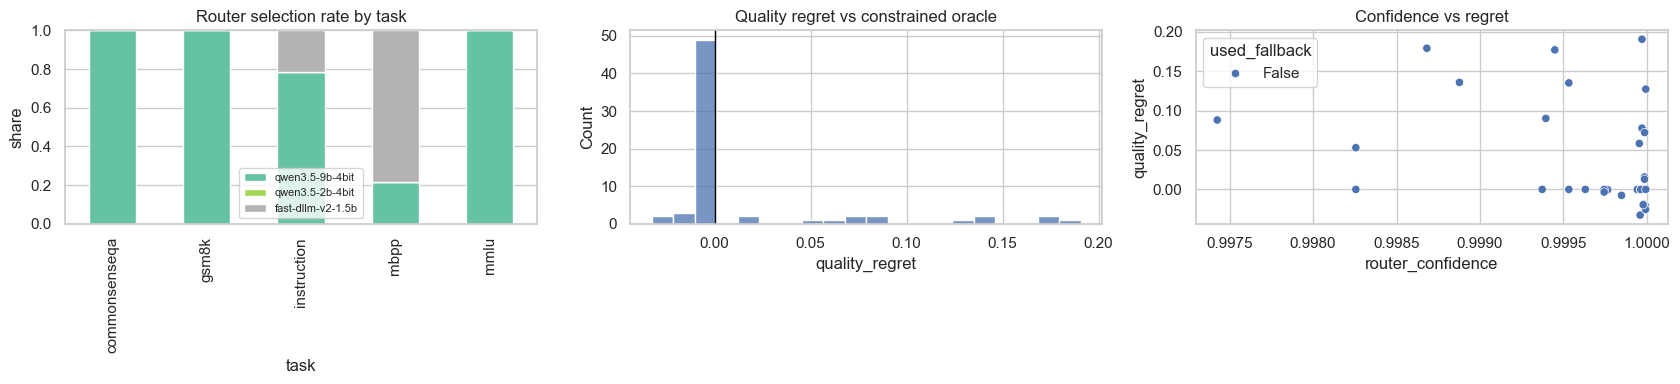

,prompts,mean_quality,mean_latency_s,mean_regret,fallback_rate
task,,,,,
mbpp,14,0.7041,1.5565,0.0611,0.0
instruction,14,0.7255,2.6696,0.0220,0.0
gsm8k,13,0.7505,2.5825,0.0098,0.0
commonsenseqa,14,0.7770,2.0572,0.0040,0.0
mmlu,13,0.7756,2.2924,-0.0046,0.0


,prompt_id,task,selected_model,router_confidence,used_fallback,realized_quality,realized_latency_s,oracle_model,quality_regret,prompt
0,demo-00009,instruction,fast-dllm-v2-1.5b,0.999970,False,0.673191,0.914526,qwen3.5-9b-4bit,0.190793,Follow all constraints in instruction 9; complexity 0.49.
1,demo-00202,mbpp,fast-dllm-v2-1.5b,0.998682,False,0.703916,0.628229,qwen3.5-9b-4bit,0.179341,Write a Python function for programming task 202; estimated difficulty 0.10.
2,demo-00357,mbpp,fast-dllm-v2-1.5b,0.999448,False,0.702602,0.916801,qwen3.5-9b-4bit,0.177246,Write a Python function for programming task 357; estimated difficulty 0.41.
3,demo-00122,mbpp,fast-dllm-v2-1.5b,0.998877,False,0.604550,1.101152,qwen3.5-9b-4bit,0.135935,Write a Python function for programming task 122; estimated difficulty 0.75.
4,demo-00172,mbpp,fast-dllm-v2-1.5b,0.999532,False,0.608227,1.264001,qwen3.5-9b-4bit,0.135282,Write a Python function for programming task 172; estimated difficulty 0.72.
5,demo-00435,gsm8k,qwen3.5-9b-4bit,0.999993,False,0.594537,2.873785,fast-dllm-v2-1.5b,0.127446,"Solve this grade-school word problem and show the final number: case 435, difficulty 0.62."
6,demo-00327,mbpp,fast-dllm-v2-1.5b,0.999394,False,0.630517,1.450944,qwen3.5-9b-4bit,0.090198,Write a Python function for programming task 327; estimated difficulty 0.81.
7,demo-00302,mbpp,fast-dllm-v2-1.5b,0.997426,False,0.673725,1.051032,qwen3.5-9b-4bit,0.088195,Write a Python function for programming task 302; estimated difficulty 0.45.
8,demo-00159,instruction,fast-dllm-v2-1.5b,0.999970,False,0.600280,0.867546,qwen3.5-9b-4bit,0.077821,Follow all constraints in instruction 159; complexity 0.46.
9,demo-00428,commonsenseqa,qwen3.5-9b-4bit,0.999986,False,0.581359,2.758715,qwen3.5-2b-4bit,0.072179,Answer commonsense scenario 428 with one choice; ambiguity 0.53.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

selection_by_task.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Router selection rate by task")
axes[0].set_ylabel("share")
axes[0].legend(fontsize=8)

sns.histplot(test_report["quality_regret"], bins=20, ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Quality regret vs constrained oracle")

sns.scatterplot(
    data=test_report,
    x="router_confidence",
    y="quality_regret",
    hue="used_fallback",
    ax=axes[2],
)
axes[2].set_title("Confidence vs regret")
plt.tight_layout()
plt.show()

task_diagnostics = test_report.groupby("task").agg(
    prompts=("prompt_id", "size"),
    mean_quality=("realized_quality", "mean"),
    mean_latency_s=("realized_latency_s", "mean"),
    mean_regret=("quality_regret", "mean"),
    fallback_rate=("used_fallback", "mean"),
).sort_values("mean_regret", ascending=False)
display(task_diagnostics.round(4))
display(
    test_report.sort_values("quality_regret", ascending=False)
    .head(10)
    .merge(prompt_table[["prompt_id", "prompt"]], on="prompt_id", how="left")
)

In [26]:
# DEBUG 12 — detect task-level collapse and suspicious confidence.
assert task_diagnostics["prompts"].sum() == n_test
assert task_diagnostics[["mean_quality", "mean_latency_s", "mean_regret"]].notna().all().all()
assert test_report["router_confidence"].between(0, 1).all()

missing_selections = set(MODELS) - set(test_report["selected_model"])
if missing_selections:
    warnings.warn(
        f"No test prompts routed to {sorted(missing_selections)}. "
        "This may be valid, but check complementarity, labels, and calibration."
    )
print("DEBUG 12 passed.")

DEBUG 12 passed.


C:\Users\bbattaglia\AppData\Local\Temp\ipykernel_37668\978793610.py:8: UserWarning: No test prompts routed to ['qwen3.5-2b-4bit']. This may be valid, but check complementarity, labels, and calibration.
  warnings.warn(


## 13. Artifact export and single-prompt inference contract

Export only after replacing synthetic data with real measurements and training the final ModernBERT model. The artifact must include candidate order, strongest fallback, latency coefficients, and selector thresholds; otherwise a reordered model list can silently corrupt routing.

In [27]:
artifact_manifest = {
    "schema_version": 1,
    "active_router": ACTIVE_ROUTER,
    "candidate_models": MODELS,
    "strongest_model": CFG.strongest_model,
    "selector_epsilon": SELECTOR_EPSILON,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "oracle_hyperparameters": {
        "epsilon": CFG.oracle_epsilon,
        "latency_weight": CFG.oracle_latency_weight,
        "temperature": CFG.oracle_temperature,
    },
    "latency_coefficients": latency_coefficients.reset_index().to_dict(orient="records"),
    "data_mode": "demo" if CFG.demo_mode else "measured",
}

def choose_from_predictions(
    quality_prediction: np.ndarray,
    output_token_prediction: np.ndarray,
    policy_probability: np.ndarray,
    manifest: dict,
) -> str:
    quality_prediction = np.asarray(quality_prediction, dtype=float).reshape(1, -1)
    output_token_prediction = np.asarray(output_token_prediction, dtype=float).reshape(1, -1)
    policy_probability = np.asarray(policy_probability, dtype=float).reshape(1, -1)
    coefficients = pd.DataFrame(manifest["latency_coefficients"]).set_index("model").loc[MODELS]
    latency = (
        coefficients["intercept_s"].to_numpy()[None, :]
        + coefficients["seconds_per_output_token"].to_numpy()[None, :] * output_token_prediction
    )
    picked, _, _ = select_models(
        quality_prediction,
        latency,
        policy_probability,
        epsilon=float(manifest["selector_epsilon"]),
        confidence_threshold=float(manifest["confidence_threshold"]),
    )
    return MODELS[int(picked[0])]

EXPORT_ARTIFACTS = False
if EXPORT_ARTIFACTS:
    if CFG.demo_mode:
        raise RuntimeError("Do not export production artifacts from synthetic measurements.")
    artifact_dir = PROJECT_ROOT / "artifacts"
    artifact_dir.mkdir(parents=True, exist_ok=True)
    (artifact_dir / "router_manifest.json").write_text(
        json.dumps(artifact_manifest, indent=2),
        encoding="utf-8",
    )
    if RUN_MODERNBERT:
        router_model.save_pretrained(artifact_dir / "modernbert_router")
        tokenizer.save_pretrained(artifact_dir / "modernbert_router")

print(json.dumps(artifact_manifest, indent=2)[:2000])

{
  "schema_version": 1,
  "active_router": "tfidf-ridge-debug-baseline",
  "candidate_models": [
    "qwen3.5-9b-4bit",
    "qwen3.5-2b-4bit",
    "fast-dllm-v2-1.5b"
  ],
  "strongest_model": "qwen3.5-9b-4bit",
  "selector_epsilon": 0.1,
  "confidence_threshold": 0.34,
  "oracle_hyperparameters": {
    "epsilon": 0.05,
    "latency_weight": 0.06,
    "temperature": 0.08
  },
  "latency_coefficients": [
    {
      "model": "qwen3.5-9b-4bit",
      "intercept_s": 0.1492292229175467,
      "seconds_per_output_token": 0.018015413528120413,
      "train_mae_s": 0.12835355675588894,
      "train_r2": 0.9557804924652724
    },
    {
      "model": "qwen3.5-2b-4bit",
      "intercept_s": 0.06669803993820644,
      "seconds_per_output_token": 0.008143827521827214,
      "train_mae_s": 0.11686168973906222,
      "train_r2": 0.8046242109687118
    },
    {
      "model": "fast-dllm-v2-1.5b",
      "intercept_s": 0.12240988268082897,
      "seconds_per_output_token": 0.006001648293272008,
     

In [28]:
# DEBUG 13 — manifest round trip and inference contract.
round_tripped = json.loads(json.dumps(artifact_manifest))
assert round_tripped["candidate_models"] == MODELS
assert round_tripped["strongest_model"] == CFG.strongest_model
assert len(round_tripped["latency_coefficients"]) == len(MODELS)

sample_idx = np.flatnonzero(test_mask)[0]
sample_choice = choose_from_predictions(
    active_quality_pred[sample_idx],
    np.expm1(active_token_log_pred[sample_idx]),
    active_policy_prob[sample_idx],
    round_tripped,
)
assert sample_choice in MODELS
print("Sample routed to:", sample_choice)
print("DEBUG 13 passed.")

Sample routed to: qwen3.5-9b-4bit
DEBUG 13 passed.


## 14. Recommended build order

1. Run this notebook unchanged and read every debug output.
2. Normalize a small RouterBench slice to exercise ingestion and oracle code. Do not report its API-model latency as local candidate latency.
3. Build a stratified local subset of 1,500–3,000 prompts with immutable IDs and references.
4. Smoke-test each candidate; use the 1.5B Fast-dLLM unless 7B reliably fits with the same output cap.
5. Benchmark one warm loaded model at a time and preserve per-model caches.
6. Score deterministic tasks with official metrics/tests; audit any judge-based labels.
7. Run the CPU baseline. If it cannot beat sensible fixed baselines, investigate data and complementarity before fine-tuning.
8. Fine-tune ModernBERT, calibrate on validation only, then open the test report once.
9. Repeat across seeds and report mean plus uncertainty.

### Before calling the MVP successful

- Similar quality to the strongest model, with a predeclared acceptable margin.
- Material reduction in controlled warm-model latency.
- Lower strongest-model usage.
- Non-degenerate use of both autoregressive and diffusion candidates, if supported by their measured quality.
- Oracle headroom that shows routing is learnable.
- No prompt leakage and no test-driven threshold tuning.

Latency claims must be phrased as **controlled warm-model inference on one Colab GPU**, not production serving latency.